# Метрики ViT-сегментации (SegFormer-B4)

Оценка на **полном** Agriculture-Vision val. Метрики ТЗ §5.1: IoU ≥ 0.90, Precision ≥ 0.90, Recall ≥ 0.95.

In [1]:
from __future__ import annotations

from contextlib import nullcontext
from pathlib import Path
from typing import Any

import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import yaml
from matplotlib.patches import Patch
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import SegformerConfig, SegformerForSemanticSegmentation

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

_cwd = Path.cwd().resolve()
ROOT = _cwd if (_cwd / "field_detecter").is_dir() else _cwd.parent

CHECKPOINT = ROOT / "model/weights/best_iou.pth"
CONFIG_PATH = ROOT / "config/agvision.yaml"
DATA_ROOT = ROOT / "data/agvision"

USE_TTA = True
THRESHOLD = 0.5
FP16 = True

assert CHECKPOINT.is_file(), f"Нет чекпоинта: {CHECKPOINT}"
assert CONFIG_PATH.is_file(), f"Нет конфига: {CONFIG_PATH}"
assert torch.cuda.is_available(), "Нужна GPU (cuda)"

device = torch.device("cuda")
print("ROOT:", ROOT)
print("GPU:", torch.cuda.get_device_name(0))
print("Чекпоинт:", CHECKPOINT)

ROOT: /home/eq/techlb/field_detecter
GPU: NVIDIA GeForce RTX 3060
Чекпоинт: /home/eq/techlb/field_detecter/model/weights/best_iou.pth


In [2]:
with CONFIG_PATH.open(encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

seg_cfg = cfg["segmentation"]
data_cfg = cfg["data"]
tz_targets = cfg["tz_targets"]
TILE_SIZE = data_cfg["tile_size"]
VAL_BATCH = seg_cfg["val_batch_size"]
NUM_WORKERS = seg_cfg["num_workers"]
MODEL_ID = seg_cfg["model_id"]
NUM_LABELS = seg_cfg["num_labels"]

print("model_id:", MODEL_ID)
print("tile_size:", TILE_SIZE)
print("tz_targets:", tz_targets)

model_id: nvidia/segformer-b4-finetuned-ade-512-512
tile_size: 512
tz_targets: {'iou_mean': 0.9, 'precision_mean': 0.9, 'recall_mean': 0.95, 'f1_macro': 0.8}


## Метрики

In [3]:
def binary_mask_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = (pred > 0).astype(bool)
    gt = (gt > 0).astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    if union == 0:
        return 1.0 if inter == 0 else 0.0
    return float(inter / union)


def precision_recall(pred: np.ndarray, gt: np.ndarray) -> tuple[float, float]:
    pred = (pred > 0).astype(bool)
    gt = (gt > 0).astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    precision = float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0
    recall = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0
    return precision, recall


def evaluate_masks(pairs: list[tuple[np.ndarray, np.ndarray]]) -> dict[str, float]:
    ious, precs, recs = [], [], []
    for pred, gt in pairs:
        ious.append(binary_mask_iou(pred, gt))
        p, r = precision_recall(pred, gt)
        precs.append(p)
        recs.append(r)
    return {
        "iou_mean": float(np.mean(ious)) if ious else 0.0,
        "precision_mean": float(np.mean(precs)) if precs else 0.0,
        "recall_mean": float(np.mean(recs)) if recs else 0.0,
        "n_samples": len(pairs),
    }


def evaluate_masks_masked(
    triples: list[tuple[np.ndarray, np.ndarray, np.ndarray]],
) -> dict[str, float]:
    pairs = []
    for pred, gt, valid in triples:
        vm = valid.astype(bool)
        if not vm.any():
            continue
        pairs.append((pred[vm], gt[vm]))
    return evaluate_masks(pairs)


def compare_to_tz_targets(
    metrics: dict[str, float],
    *,
    targets: dict[str, float] | None = None,
) -> dict[str, Any]:
    if targets is None:
        targets = {"iou_mean": 0.90, "precision_mean": 0.90, "recall_mean": 0.95}
    status = {
        k: {
            "value": metrics.get(k, 0.0),
            "target": targets[k],
            "passed": metrics.get(k, 0.0) >= targets[k],
        }
        for k in targets
        if k in ("iou_mean", "precision_mean", "recall_mean", "f1_macro")
    }
    return {"metrics": metrics, "tz_targets": status}


m = np.ones((8, 8), dtype=np.uint8)
assert abs(binary_mask_iou(m, m) - 1.0) < 1e-6, "совпадающие маски → IoU=1"
z = np.zeros((8, 8), dtype=np.uint8)
assert abs(binary_mask_iou(z, z) - 1.0) < 1e-6, "пустые маски → IoU=1"
assert abs(binary_mask_iou(m, z) - 0.0) < 1e-6, "нет пересечения → IoU=0"
vm = np.zeros((4, 4), dtype=np.uint8)
vm[1:3, 1:3] = 1
triples = [(m[:4, :4], m[:4, :4], vm)]
masked = evaluate_masks_masked(triples)
assert masked["iou_mean"] == 1.0, "valid_mask ограничивает область подсчёта"
print("Санити-тесты метрик: OK")

Санити-тесты метрик: OK


## Датасет val

In [4]:
import re

FIELD_ID_RE = re.compile(r"^([A-Z0-9]+)_")


def parse_field_id(stem: str) -> str:
    m = FIELD_ID_RE.match(stem)
    return m.group(1) if m else stem.split("_")[0]


def discover_split_root(data_root: Path, version_dir: str, split: str) -> Path:
    candidates = [
        data_root / version_dir / split,
        data_root / split,
        data_root / f"{version_dir}-{split}",
    ]
    for p in candidates:
        if (p / "images" / "rgb").is_dir() or (p / "images" / "nir").is_dir():
            return p
    raise FileNotFoundError(f"Split '{split}' не найден в {data_root}")


def _resolve_label_path(split_root: Path, name: str, stem: str) -> Path | None:
    for ext in (".png", ".jpg"):
        p = split_root / name / f"{stem}{ext}"
        if p.is_file():
            return p
    return None


def list_tile_stems(split_root: Path) -> list[str]:
    rgb_dir = split_root / "images" / "rgb"
    stems = sorted(p.stem for p in rgb_dir.glob("*.png"))
    if not stems:
        stems = sorted(p.stem for p in rgb_dir.glob("*.jpg"))
    return stems


def load_agvision_tile(split_root: Path, stem: str, *, tile_size: int = 512) -> dict[str, Any]:
    rgb_path = split_root / "images" / "rgb" / f"{stem}.png"
    if not rgb_path.exists():
        rgb_path = split_root / "images" / "rgb" / f"{stem}.jpg"
    nir_path = split_root / "images" / "nir" / f"{stem}.png"
    if not nir_path.exists():
        nir_path = split_root / "images" / "nir" / f"{stem}.jpg"
    bnd_path = _resolve_label_path(split_root, "boundaries", stem)
    mask_path = _resolve_label_path(split_root, "masks", stem)

    rgb = cv2.cvtColor(cv2.imread(str(rgb_path)), cv2.COLOR_BGR2RGB)
    nir = cv2.imread(str(nir_path), cv2.IMREAD_GRAYSCALE)
    boundary = cv2.imread(str(bnd_path), cv2.IMREAD_GRAYSCALE) if bnd_path else None
    valid = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) if mask_path else None

    if rgb.shape[:2] != (tile_size, tile_size):
        rgb = cv2.resize(rgb, (tile_size, tile_size), interpolation=cv2.INTER_LINEAR)
    if nir.shape != (tile_size, tile_size):
        nir = cv2.resize(nir, (tile_size, tile_size), interpolation=cv2.INTER_LINEAR)
    if boundary is None:
        boundary = np.zeros((tile_size, tile_size), dtype=np.uint8)
    elif boundary.shape != (tile_size, tile_size):
        boundary = cv2.resize(boundary, (tile_size, tile_size), interpolation=cv2.INTER_NEAREST)
    if valid is None:
        valid = np.ones((tile_size, tile_size), dtype=np.uint8) * 255
    elif valid.shape != (tile_size, tile_size):
        valid = cv2.resize(valid, (tile_size, tile_size), interpolation=cv2.INTER_NEAREST)

    image_4ch = np.stack([nir, rgb[..., 0], rgb[..., 1], rgb[..., 2]], axis=0).astype(np.float32) / 255.0
    return {
        "image": image_4ch,
        "boundary": (boundary > 0).astype(np.uint8),
        "valid_mask": (valid > 0).astype(np.uint8),
        "field_id": parse_field_id(stem),
        "stem": stem,
        "rgb": rgb,
    }


class AgVisionDataset(Dataset):
    def __init__(
        self,
        data_root: str | Path,
        split: str = "val",
        *,
        version_dir: str = "Agriculture-Vision-2021",
        tile_size: int = 512,
        max_samples: int | None = None,
    ) -> None:
        self.tile_size = tile_size
        self.split_root = discover_split_root(Path(data_root), version_dir, split)
        self.stems = list_tile_stems(self.split_root)
        if max_samples is not None:
            self.stems = self.stems[:max_samples]

    def __len__(self) -> int:
        return len(self.stems)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        stem = self.stems[idx]
        sample = load_agvision_tile(self.split_root, stem, tile_size=self.tile_size)
        sample["labels"] = sample["boundary"].astype(np.int64)
        return sample


def collate_val_batch(batch: list[dict[str, Any]]) -> dict[str, torch.Tensor]:
    return {
        "pixel_values": torch.stack([torch.from_numpy(b["image"]) for b in batch]),
        "labels": torch.stack([torch.from_numpy(b["labels"]) for b in batch]),
        "valid_mask": torch.stack([torch.from_numpy(b["valid_mask"]) for b in batch]),
        "stems": [b["stem"] for b in batch],
    }


val_ds = AgVisionDataset(
    DATA_ROOT,
    split="val",
    version_dir=data_cfg["version_dir"],
    tile_size=TILE_SIZE,
    max_samples=None,
)

val_loader = DataLoader(
    val_ds,
    batch_size=VAL_BATCH,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_val_batch,
    pin_memory=True,
)
VAL_SPLIT_ROOT = val_ds.split_root
print(f"Тайлов val: {len(val_ds)}")

Тайлов val: 18334


## Модель и валидация

In [5]:
def _first_patch_proj(model: SegformerForSemanticSegmentation) -> torch.nn.Conv2d:
    seg = model.segformer
    if hasattr(seg, "encoder") and hasattr(seg.encoder, "patch_embed"):
        return seg.encoder.patch_embed[0].proj
    if hasattr(seg, "stages"):
        return seg.stages[0].patch_embeddings.proj
    raise AttributeError("patch embedding не найден")


def expand_segformer_to_4ch(model: SegformerForSemanticSegmentation) -> None:
    old = _first_patch_proj(model)
    if old.in_channels == 4:
        return
    new_conv = torch.nn.Conv2d(
        4, old.out_channels,
        kernel_size=old.kernel_size, stride=old.stride,
        padding=old.padding, bias=old.bias is not None,
    )
    with torch.no_grad():
        new_conv.weight[:, 0] = old.weight.mean(dim=1)
        new_conv.weight[:, 1] = old.weight[:, 0]
        new_conv.weight[:, 2] = old.weight[:, 1]
        new_conv.weight[:, 3] = old.weight[:, 2]
        if old.bias is not None:
            new_conv.bias.copy_(old.bias)
    if hasattr(model.segformer, "stages"):
        model.segformer.stages[0].patch_embeddings.proj = new_conv
    else:
        model.segformer.encoder.patch_embed[0].proj = new_conv


def load_segformer_binary(model_id: str, num_labels: int = 2) -> SegformerForSemanticSegmentation:
    config = SegformerConfig.from_pretrained(model_id)
    config.num_labels = num_labels
    config.id2label = {str(i): ("background", "boundary")[i] for i in range(num_labels)}
    config.label2id = {v: k for k, v in config.id2label.items()}
    return SegformerForSemanticSegmentation.from_pretrained(
        model_id, config=config, ignore_mismatched_sizes=True,
    )


class Segformer4ChWrapper(torch.nn.Module):
    def __init__(self, model_id: str, num_labels: int = 2) -> None:
        super().__init__()
        self.model = load_segformer_binary(model_id, num_labels=num_labels)
        expand_segformer_to_4ch(self.model)

    def forward(self, pixel_values: torch.Tensor, labels: torch.Tensor | None = None):
        return self.model(pixel_values=pixel_values, labels=labels)


def _amp_ctx(enabled: bool):
    if not enabled:
        return nullcontext()
    if hasattr(torch.amp, "autocast"):
        return torch.amp.autocast("cuda")
    return torch.cuda.amp.autocast()


def _forward_prob(
    model: Segformer4ChWrapper,
    x: torch.Tensor,
    *,
    tta: bool,
    fp16: bool,
) -> np.ndarray:
    """Вероятность boundary B×H×W float32 на CPU."""
    with _amp_ctx(fp16):
        if tta:
            probs_list = []
            for flip in ((), (2,), (3,)):
                xi = x if not flip else x.flip(flip)
                lo = model(xi).logits
                if lo.shape[-2:] != x.shape[-2:]:
                    lo = F.interpolate(lo, size=x.shape[-2:], mode="bilinear", align_corners=False)
                lo = lo if not flip else lo.flip(flip)
                probs_list.append(lo.softmax(dim=1))
            prob = torch.stack(probs_list).mean(0)[:, 1]
        else:
            lo = model(x).logits
            if lo.shape[-2:] != x.shape[-2:]:
                lo = F.interpolate(lo, size=x.shape[-2:], mode="bilinear", align_corners=False)
            prob = lo.softmax(dim=1)[:, 1]
    return prob.float().cpu().numpy()


@torch.no_grad()
def run_validation_full(
    model: Segformer4ChWrapper,
    loader: DataLoader,
    device: torch.device,
    *,
    threshold: float = 0.5,
    tta: bool = True,
    fp16: bool = True,
) -> tuple[dict[str, float], list[dict[str, float | str]]]:
    """Только скаляры per-tile — без хранения масок (18k тайлов ≈ 45 ГБ иначе)."""
    model.eval()
    per_tile: list[dict[str, float | str]] = []

    for batch in tqdm(loader, desc="val (полный)"):
        x = batch["pixel_values"].to(device, non_blocking=True)
        vm_np = batch["valid_mask"].numpy()
        labels_np = batch["labels"].numpy()
        stems = batch["stems"]

        prob = _forward_prob(model, x, tta=tta, fp16=fp16)
        pred = (prob >= threshold).astype(np.uint8)

        for i in range(pred.shape[0]):
            p, g, v = pred[i], labels_np[i], vm_np[i]
            vm = v.astype(bool)
            if vm.any():
                iou = binary_mask_iou(p[vm], g[vm])
                prec, rec = precision_recall(p[vm], g[vm])
            else:
                iou, prec, rec = 0.0, 0.0, 0.0
            per_tile.append({
                "stem": stems[i],
                "iou": iou,
                "precision": prec,
                "recall": rec,
            })

        del x, prob, pred, batch

    ious = [t["iou"] for t in per_tile]
    precs = [t["precision"] for t in per_tile]
    recs = [t["recall"] for t in per_tile]
    metrics = {
        "iou_mean": float(np.mean(ious)),
        "precision_mean": float(np.mean(precs)),
        "recall_mean": float(np.mean(recs)),
        "n_samples": len(per_tile),
    }
    return metrics, per_tile


def load_segformer_checkpoint(ckpt_path: Path, device: torch.device) -> tuple[Segformer4ChWrapper, dict[str, Any]]:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    ckpt_cfg = ckpt.get("config", {})
    ckpt_seg = ckpt_cfg.get("segmentation", {})
    model_id = ckpt_seg.get("model_id", MODEL_ID)
    meta = {
        "epoch": ckpt.get("epoch"),
        "val_metrics": ckpt.get("val_metrics", {}),
        "threshold": ckpt_seg.get("val_threshold", THRESHOLD),
    }
    model = Segformer4ChWrapper(model_id, num_labels=ckpt_seg.get("num_labels", NUM_LABELS))
    model.load_state_dict(ckpt["model_state"])
    del ckpt
    model.to(device)
    model.eval()
    return model, meta


@torch.no_grad()
def infer_tiles_for_viz(
    model: Segformer4ChWrapper,
    split_root: Path,
    stems: list[str],
    device: torch.device,
    *,
    tile_size: int = 512,
    threshold: float = 0.5,
    tta: bool = True,
    fp16: bool = True,
) -> list[dict[str, Any]]:
    """Инференс только для выбранных тайлов (визуализация)."""
    model.eval()
    out: list[dict[str, Any]] = []
    for stem in stems:
        sample = load_agvision_tile(split_root, stem, tile_size=tile_size)
        x = torch.from_numpy(sample["image"]).unsqueeze(0).to(device)
        prob = _forward_prob(model, x, tta=tta, fp16=fp16)[0]
        pred = (prob >= threshold).astype(np.uint8)
        gt, valid, rgb = sample["boundary"], sample["valid_mask"], sample["rgb"]
        vm = valid.astype(bool)
        iou = binary_mask_iou(pred[vm], gt[vm]) if vm.any() else 0.0
        prec, rec = precision_recall(pred[vm], gt[vm]) if vm.any() else (0.0, 0.0)
        out.append({
            "stem": stem,
            "iou": iou,
            "precision": prec,
            "recall": rec,
            "pred": pred,
            "gt": gt,
            "valid": valid,
            "prob": prob,
            "rgb": rgb,
        })
        del x, prob, pred
    return out


model, meta = load_segformer_checkpoint(CHECKPOINT, device)
print("epoch в чекпоинте:", meta.get("epoch"))
print("val_metrics в чекпоинте:", meta.get("val_metrics"))

metrics, per_tile = run_validation_full(
    model, val_loader, device,
    threshold=THRESHOLD, tta=USE_TTA, fp16=FP16,
)
print("Итог val:", metrics)
print(f"per_tile: {len(per_tile)} записей, ~{len(per_tile)*80/1e6:.1f} МБ (только скаляры)")

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b4-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


epoch в чекпоинте: 23
val_metrics в чекпоинте: {'iou_mean': 0.9454130223379369, 'precision_mean': 0.9534832943579065, 'recall_mean': 0.9882370684422412, 'n_samples': 1000}


val (полный):   0%|          | 0/9167 [00:00<?, ?it/s]

Итог val: {'iou_mean': 0.940880640879388, 'precision_mean': 0.9569229348797582, 'recall_mean': 0.9781622553366535, 'n_samples': 18334}
per_tile: 18334 записей, ~1.5 МБ (только скаляры)


## Итоговые метрики и ТЗ

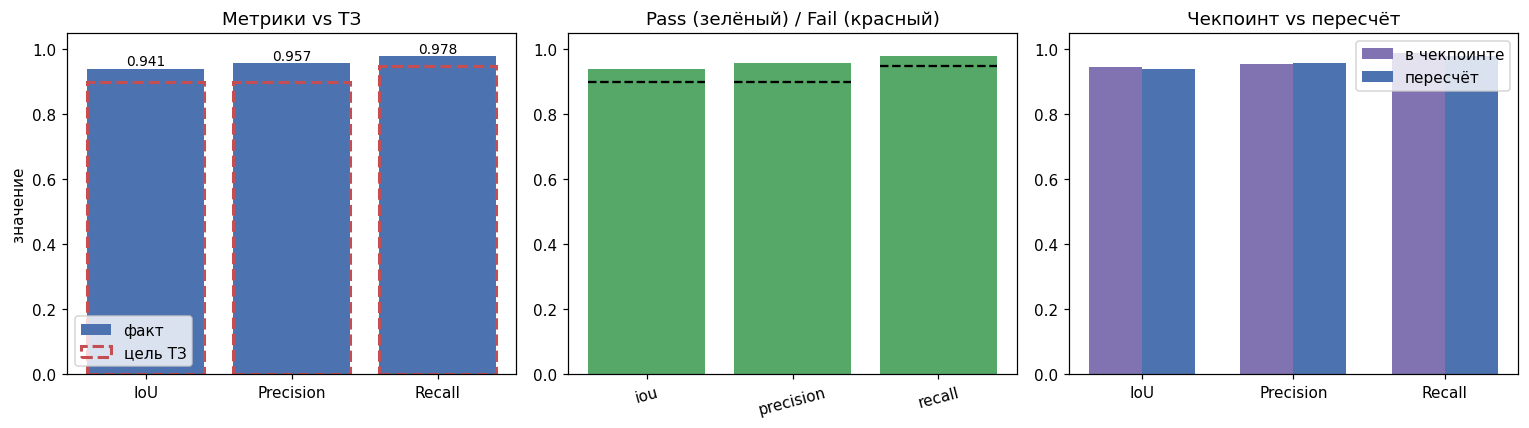

n_samples = 18334
ТЗ: ПРОЙДЕНО
  ✓ iou_mean: 0.9409 (цель 0.90)
  ✓ precision_mean: 0.9569 (цель 0.90)
  ✓ recall_mean: 0.9782 (цель 0.95)


In [6]:
tz_report = compare_to_tz_targets(metrics, targets=tz_targets)
tz_status = tz_report["tz_targets"]
metric_keys = ["iou_mean", "precision_mean", "recall_mean"]
all_passed = all(tz_status[k]["passed"] for k in metric_keys)

labels_ru = ["IoU", "Precision", "Recall"]
values = [metrics[k] for k in metric_keys]
targets = [tz_targets[k] for k in metric_keys]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
x = np.arange(len(labels_ru))
bars = ax.bar(x, values, color="#4C72B0", label="факт")
ax.bar(x, targets, fill=False, edgecolor="#C44E52", linewidth=2, linestyle="--", label="цель ТЗ")
ax.set_xticks(x)
ax.set_xticklabels(labels_ru)
ax.set_ylim(0, 1.05)
ax.set_ylabel("значение")
ax.set_title("Метрики vs ТЗ")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.legend()

ax = axes[1]
names = [n for n in tz_status if n != "f1_macro"]
passed_flags = [tz_status[k]["passed"] for k in metric_keys]
colors = ["#55A868" if p else "#C44E52" for p in passed_flags]
ax.bar(range(len(names)), [tz_status[n]["value"] for n in names], color=colors)
for i, n in enumerate(names):
    ax.hlines(tz_status[n]["target"], i - 0.4, i + 0.4, colors="black", linestyles="--")
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace("_mean", "") for n in names], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_title("Pass (зелёный) / Fail (красный)")

ax = axes[2]
ckpt_vals = [meta.get("val_metrics", {}).get(k, 0.0) for k in metric_keys]
w = 0.35
ax.bar(x - w / 2, ckpt_vals, w, label="в чекпоинте", color="#8172B2")
ax.bar(x + w / 2, values, w, label="пересчёт", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(labels_ru)
ax.set_ylim(0, 1.05)
ax.set_title("Чекпоинт vs пересчёт")
ax.legend()

plt.tight_layout()
plt.show()

print(f"n_samples = {metrics['n_samples']}")
print(f"ТЗ: {'ПРОЙДЕНО' if all_passed else 'НЕ ПРОЙДЕНО'}")
for n, s in tz_status.items():
    if n == "f1_macro":
        continue
    mark = "✓" if s["passed"] else "✗"
    print(f"  {mark} {n}: {s['value']:.4f} (цель {s['target']:.2f})")

## Распределение per-tile

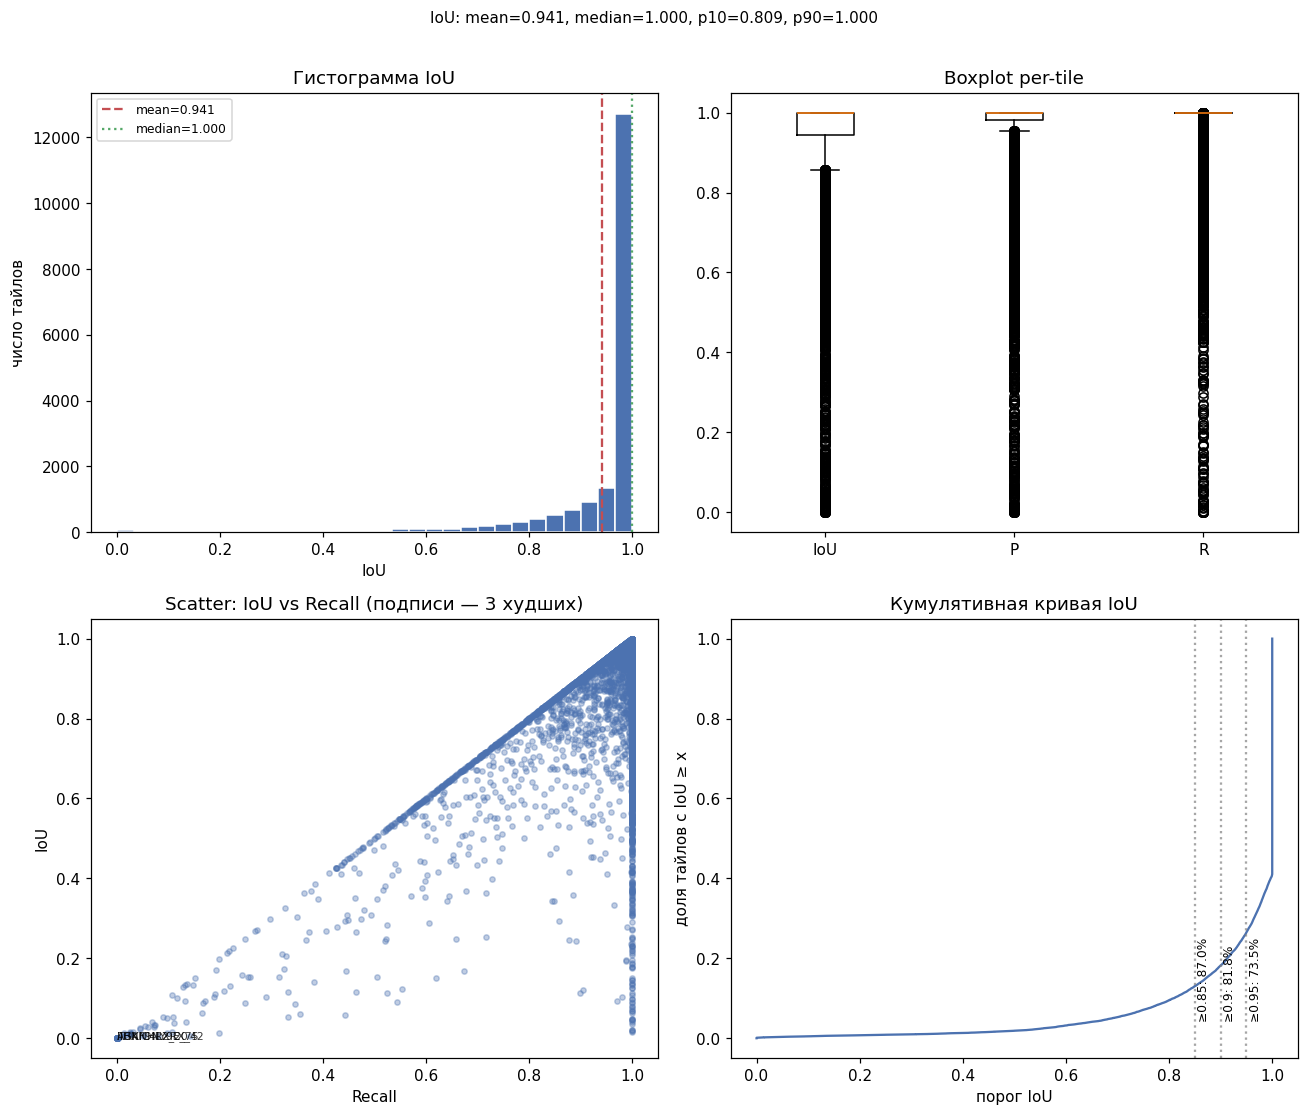

In [7]:
ious = np.array([t["iou"] for t in per_tile])
precs = np.array([t["precision"] for t in per_tile])
recs = np.array([t["recall"] for t in per_tile])

stats_txt = (
    f"IoU: mean={ious.mean():.3f}, median={np.median(ious):.3f}, "
    f"p10={np.percentile(ious, 10):.3f}, p90={np.percentile(ious, 90):.3f}"
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.hist(ious, bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(ious.mean(), color="#C44E52", linestyle="--", label=f"mean={ious.mean():.3f}")
ax.axvline(np.median(ious), color="#55A868", linestyle=":", label=f"median={np.median(ious):.3f}")
ax.set_xlabel("IoU")
ax.set_ylabel("число тайлов")
ax.set_title("Гистограмма IoU")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.boxplot([ious, precs, recs], tick_labels=["IoU", "P", "R"])
ax.set_ylim(-0.05, 1.05)
ax.set_title("Boxplot per-tile")

ax = axes[1, 0]
ax.scatter(recs, ious, alpha=0.35, s=12, c="#4C72B0")
worst_idx = np.argsort(ious)[:3]
for idx in worst_idx:
    ax.annotate(
        per_tile[idx]["stem"][:12],
        (recs[idx], ious[idx]), fontsize=7, alpha=0.8,
    )
ax.set_xlabel("Recall")
ax.set_ylabel("IoU")
ax.set_title("Scatter: IoU vs Recall (подписи — 3 худших)")

ax = axes[1, 1]
sorted_iou = np.sort(ious)
frac = np.arange(1, len(sorted_iou) + 1) / len(sorted_iou)
ax.plot(sorted_iou, frac, color="#4C72B0")
for thr in (0.85, 0.90, 0.95):
    share = (ious >= thr).mean()
    ax.axvline(thr, color="gray", linestyle=":", alpha=0.7)
    ax.text(thr + 0.005, 0.05, f"≥{thr}: {share:.1%}", fontsize=8, rotation=90)
ax.set_xlabel("порог IoU")
ax.set_ylabel("доля тайлов с IoU ≥ x")
ax.set_title("Кумулятивная кривая IoU")

fig.suptitle(stats_txt, fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

**Общая картина.** Модель оценена на каждом тайле val отдельно. IoU показывает,
насколько предсказанная граница поля совпадает с разметкой. Precision — долю
верно найденных пикселей границы среди всех предсказанных. Recall — долю
найденной разметки среди всех пикселей GT.

**Гистограмма IoU.** Пик слева — много «плохих» тайлов; пик справа (ближе к 1.0) —
много хороших. Если среднее и медиана ≥ 0.90, модель в среднем соответствует ТЗ.
Большой хвост слева — есть проблемные сцены (тени, край поля, шум NIR).

**Boxplot.** Сравнивает три метрики на одном масштабе. Узкий ящик — стабильное
качество по тайлам. Длинные «усы» и точки-выбросы — отдельные тайлы сильно
хуже/лучше среднего. Если Recall выше IoU — границу находим щедро, но с лишними
пикселями (ниже precision на отдельных тайлах).

**Scatter IoU vs Recall.** Точка = один тайл. Обычно точки идут вверх-вправо:
высокий recall при низком IoU — модель «перерисовывает» границу (широкая полоса).
Низкий recall при любом IoU — пропуски сегмента. Три подписанных тайла — кандидаты
для разбора в блоке «Примеры сегментации».

**Кумулятивная кривая.** По оси X — порог IoU, по Y — доля тайлов, которые его
проходят. Например, «≥0.90: 87%» значит: на 87% тайлов IoU не ниже 0.90.
Для ТЗ важна не только средняя метрика, но и эта доля — насколько модель стабильна
на всём val, а не только в среднем.

**Связь с итоговой ячейкой ТЗ.** Средние IoU/P/R — макро-усреднение по тайлам.
Графики здесь показывают *разброс*: модель может пройти ТЗ по среднему, но иметь
заметную долю слабых тайлов — это видно на гистограмме и кумулятивной криве.

## Примеры сегментации

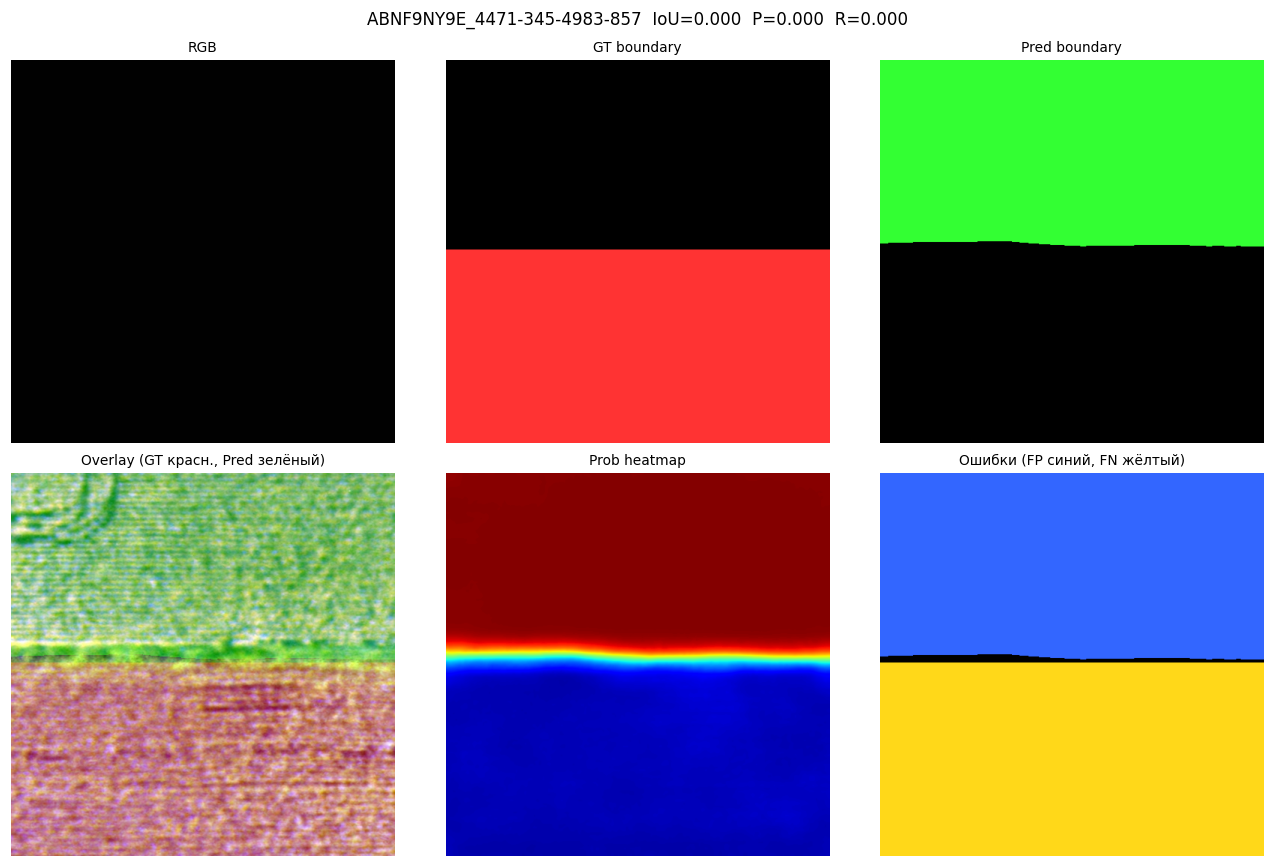

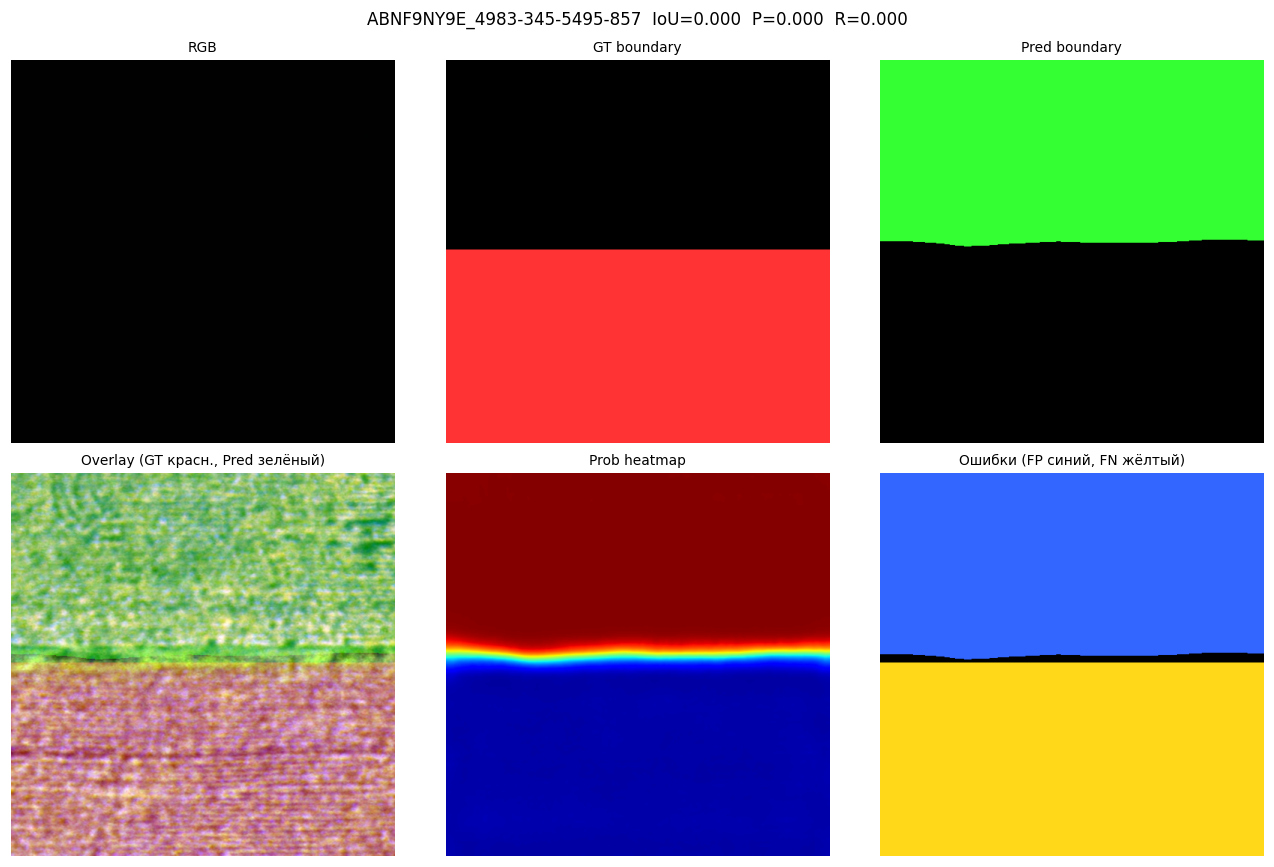

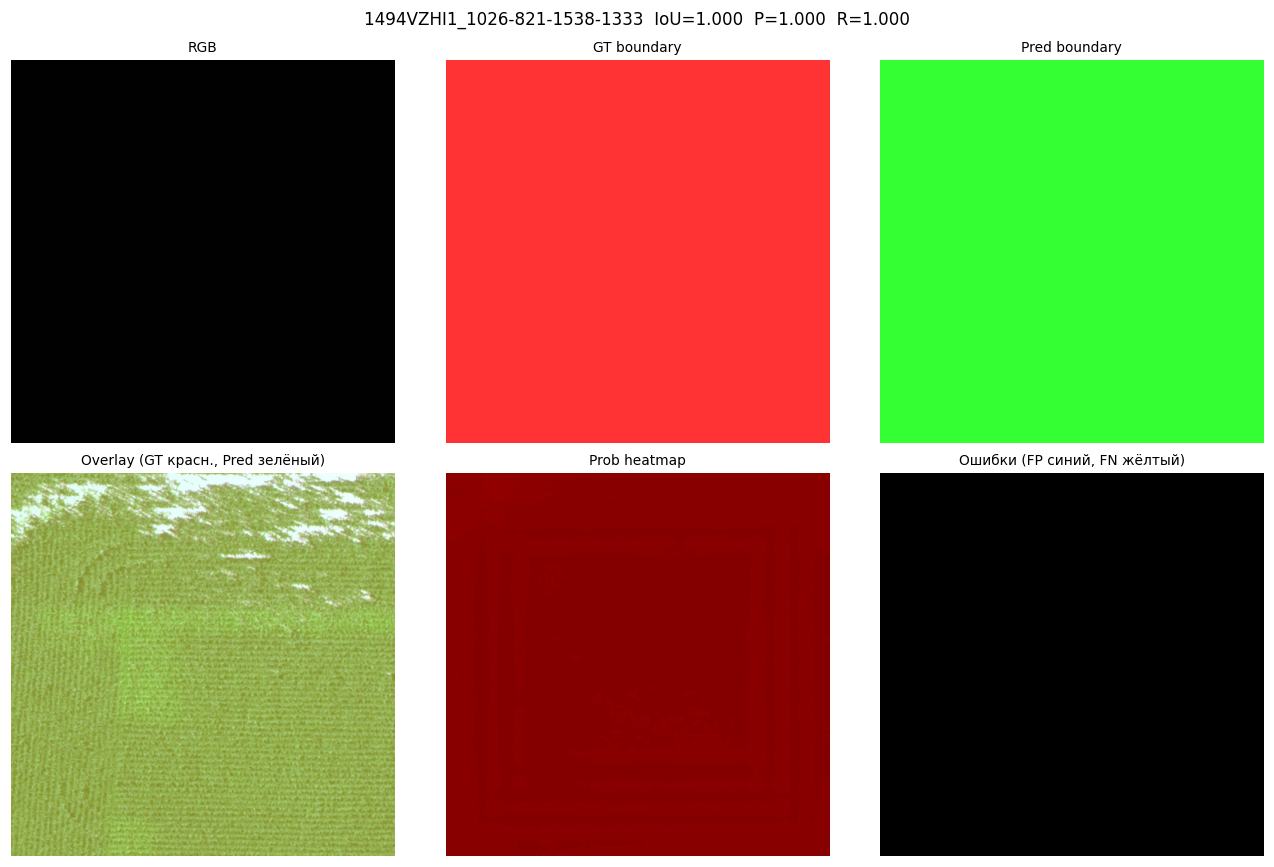

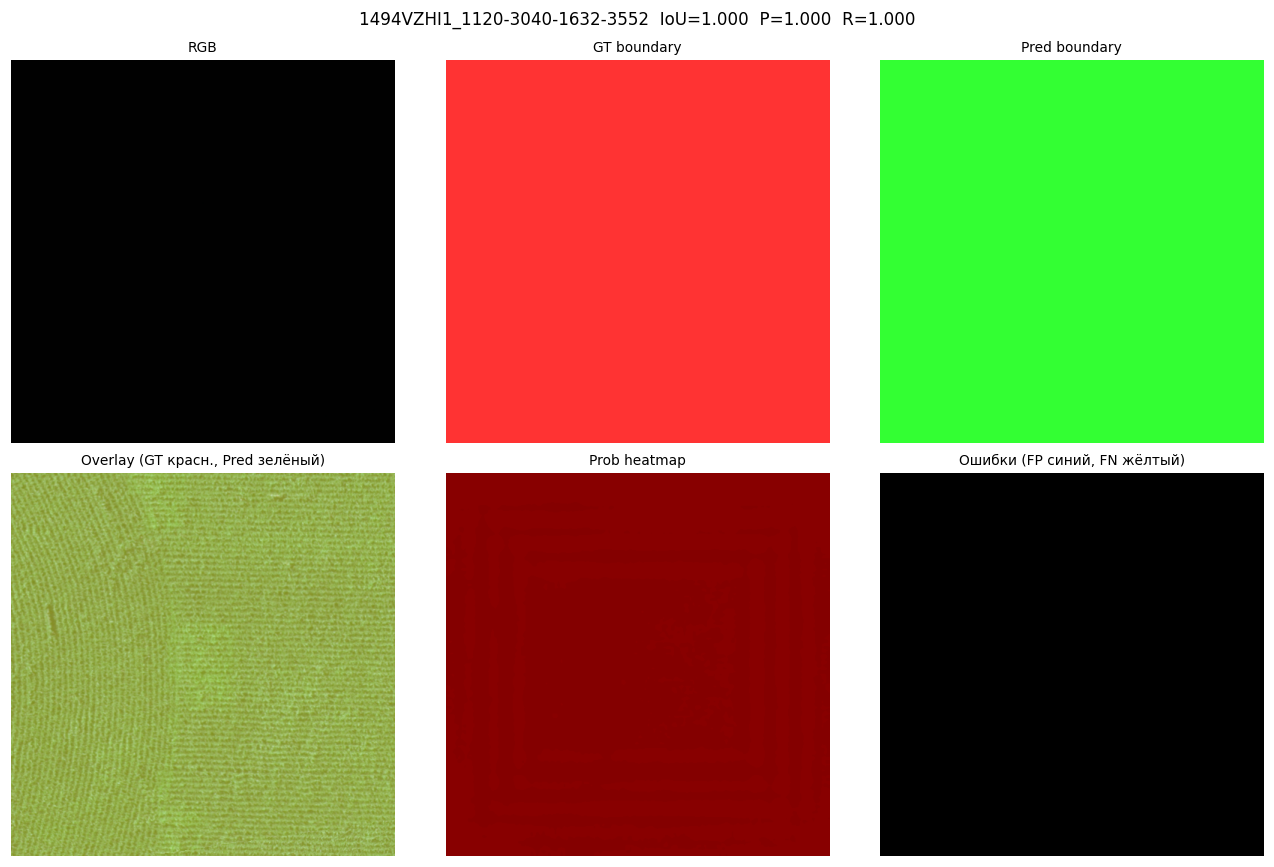

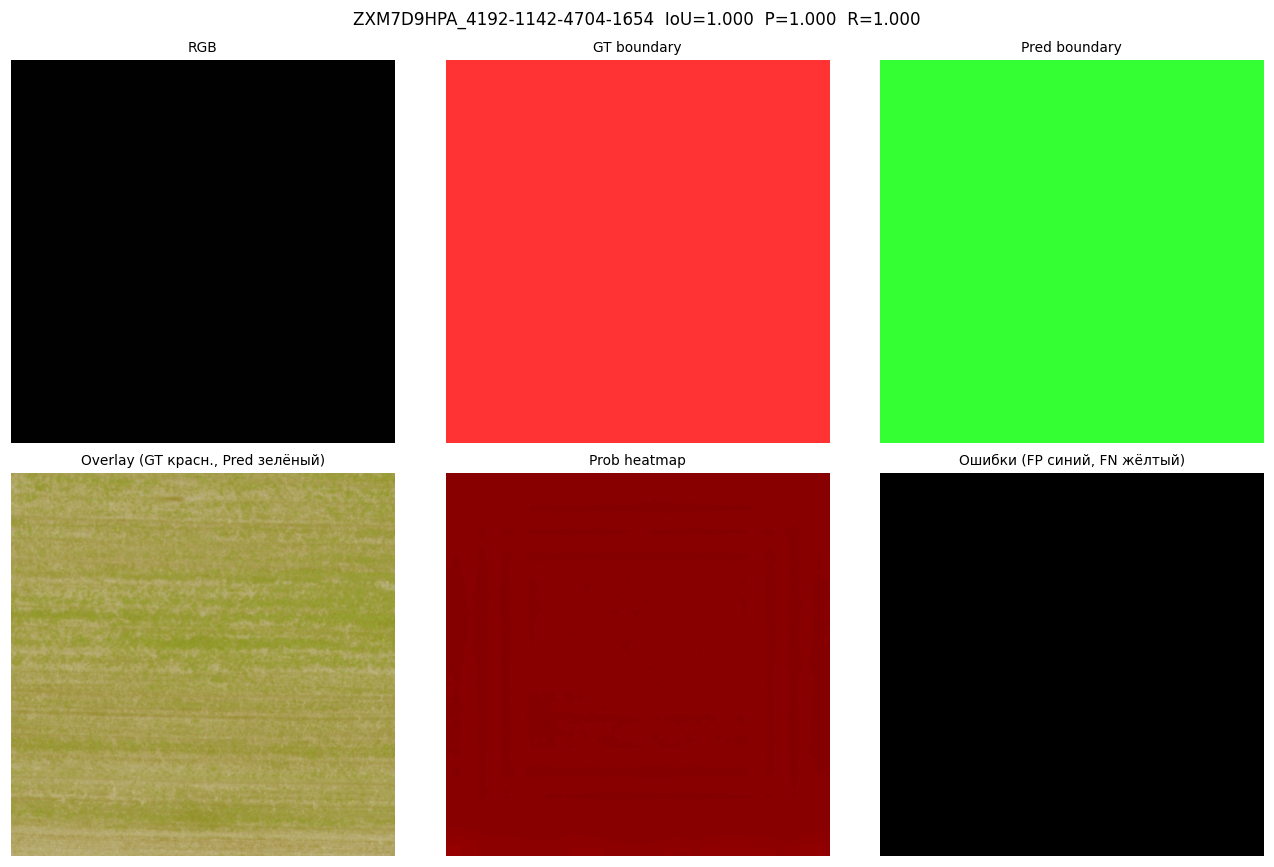

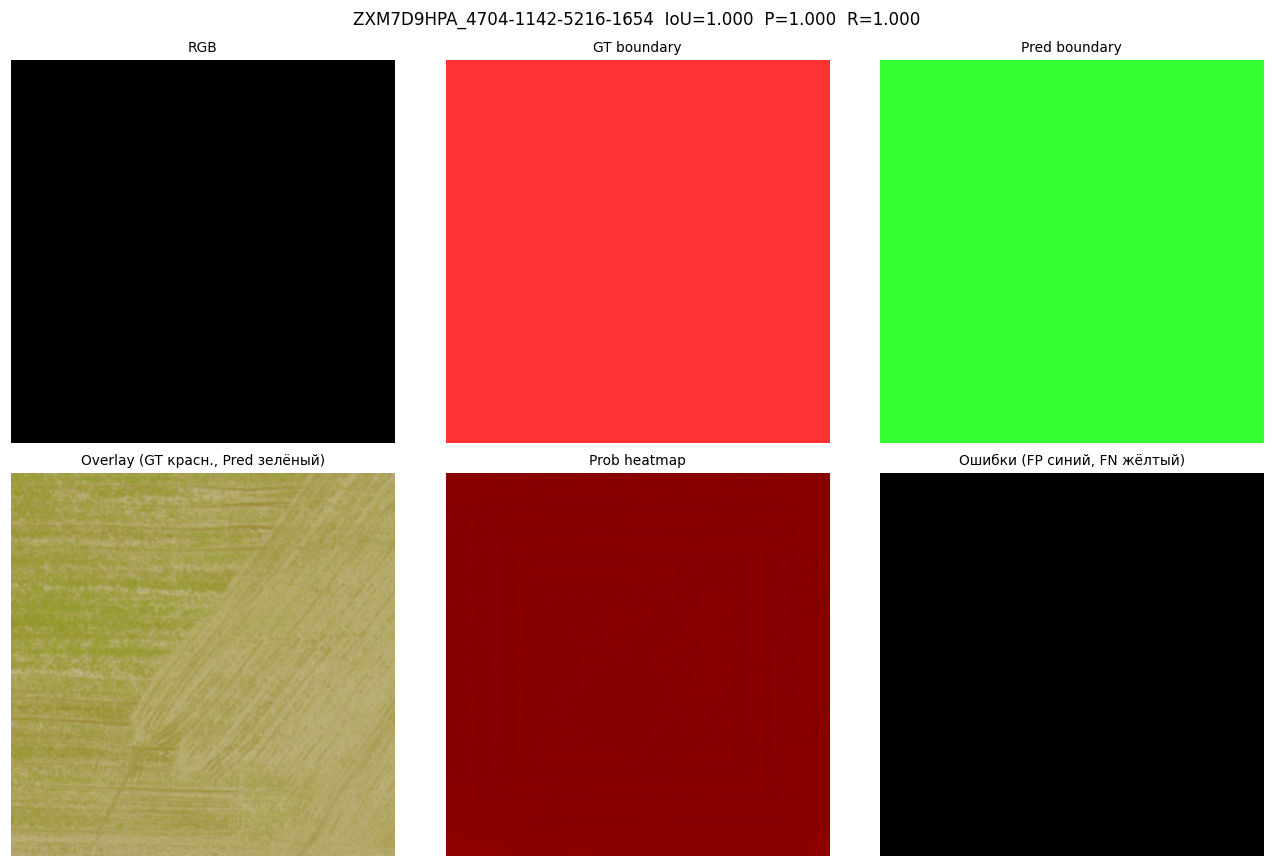

In [8]:
def _boundary_on_black(mask: np.ndarray, color: tuple[float, float, float]) -> np.ndarray:
    img = np.zeros((*mask.shape, 3), dtype=np.float32)
    img[mask > 0] = color
    return img


def _overlay(rgb: np.ndarray, gt: np.ndarray, pred: np.ndarray) -> np.ndarray:
    out = rgb.astype(np.float32) / 255.0
    out[gt > 0, 0] = np.clip(out[gt > 0, 0] * 0.5 + 0.5, 0, 1)
    out[pred > 0, 1] = np.clip(out[pred > 0, 1] * 0.5 + 0.5, 0, 1)
    return out


def _error_map(pred: np.ndarray, gt: np.ndarray, valid: np.ndarray) -> np.ndarray:
    img = np.zeros((*pred.shape, 3), dtype=np.float32)
    vm = valid.astype(bool)
    fp = vm & (pred > 0) & (gt == 0)
    fn = vm & (pred == 0) & (gt > 0)
    img[fp] = (0.2, 0.4, 1.0)
    img[fn] = (1.0, 0.85, 0.1)
    return img


def plot_tile_detail(tile: dict[str, Any]) -> None:
    rgb, gt, pred, prob, valid = tile["rgb"], tile["gt"], tile["pred"], tile["prob"], tile["valid"]
    title = f"{tile['stem']}  IoU={tile['iou']:.3f}  P={tile['precision']:.3f}  R={tile['recall']:.3f}"

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    panels = [
        (rgb, "RGB"),
        (_boundary_on_black(gt, (1, 0.2, 0.2)), "GT boundary"),
        (_boundary_on_black(pred, (0.2, 1, 0.2)), "Pred boundary"),
        (_overlay(rgb, gt, pred), "Overlay (GT красн., Pred зелёный)"),
        (prob, "Prob heatmap"),
        (_error_map(pred, gt, valid), "Ошибки (FP синий, FN жёлтый)"),
    ]
    for ax, (img, lbl) in zip(axes.ravel(), panels):
        if img.ndim == 2:
            ax.imshow(img, cmap="jet", vmin=0, vmax=1)
        else:
            ax.imshow(np.clip(img, 0, 1))
        ax.set_title(lbl, fontsize=9)
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


sorted_tiles = sorted(per_tile, key=lambda t: t["iou"])
n = len(sorted_tiles)
median_iou = float(np.median(ious))

near_med = sorted(per_tile, key=lambda t: abs(t["iou"] - median_iou))
selected_stems: list[str] = []
for group in (sorted_tiles[:2], near_med[:2], sorted_tiles[-2:]):
    for t in group:
        if t["stem"] not in selected_stems:
            selected_stems.append(t["stem"])
while len(selected_stems) < 6 and len(selected_stems) < n:
    for t in sorted_tiles:
        if t["stem"] not in selected_stems:
            selected_stems.append(t["stem"])
            break
    else:
        break

viz_tiles = infer_tiles_for_viz(
    model, VAL_SPLIT_ROOT, selected_stems[:6], device,
    tile_size=TILE_SIZE, threshold=THRESHOLD, tta=USE_TTA, fp16=FP16,
)
for tile in viz_tiles:
    plot_tile_detail(tile)

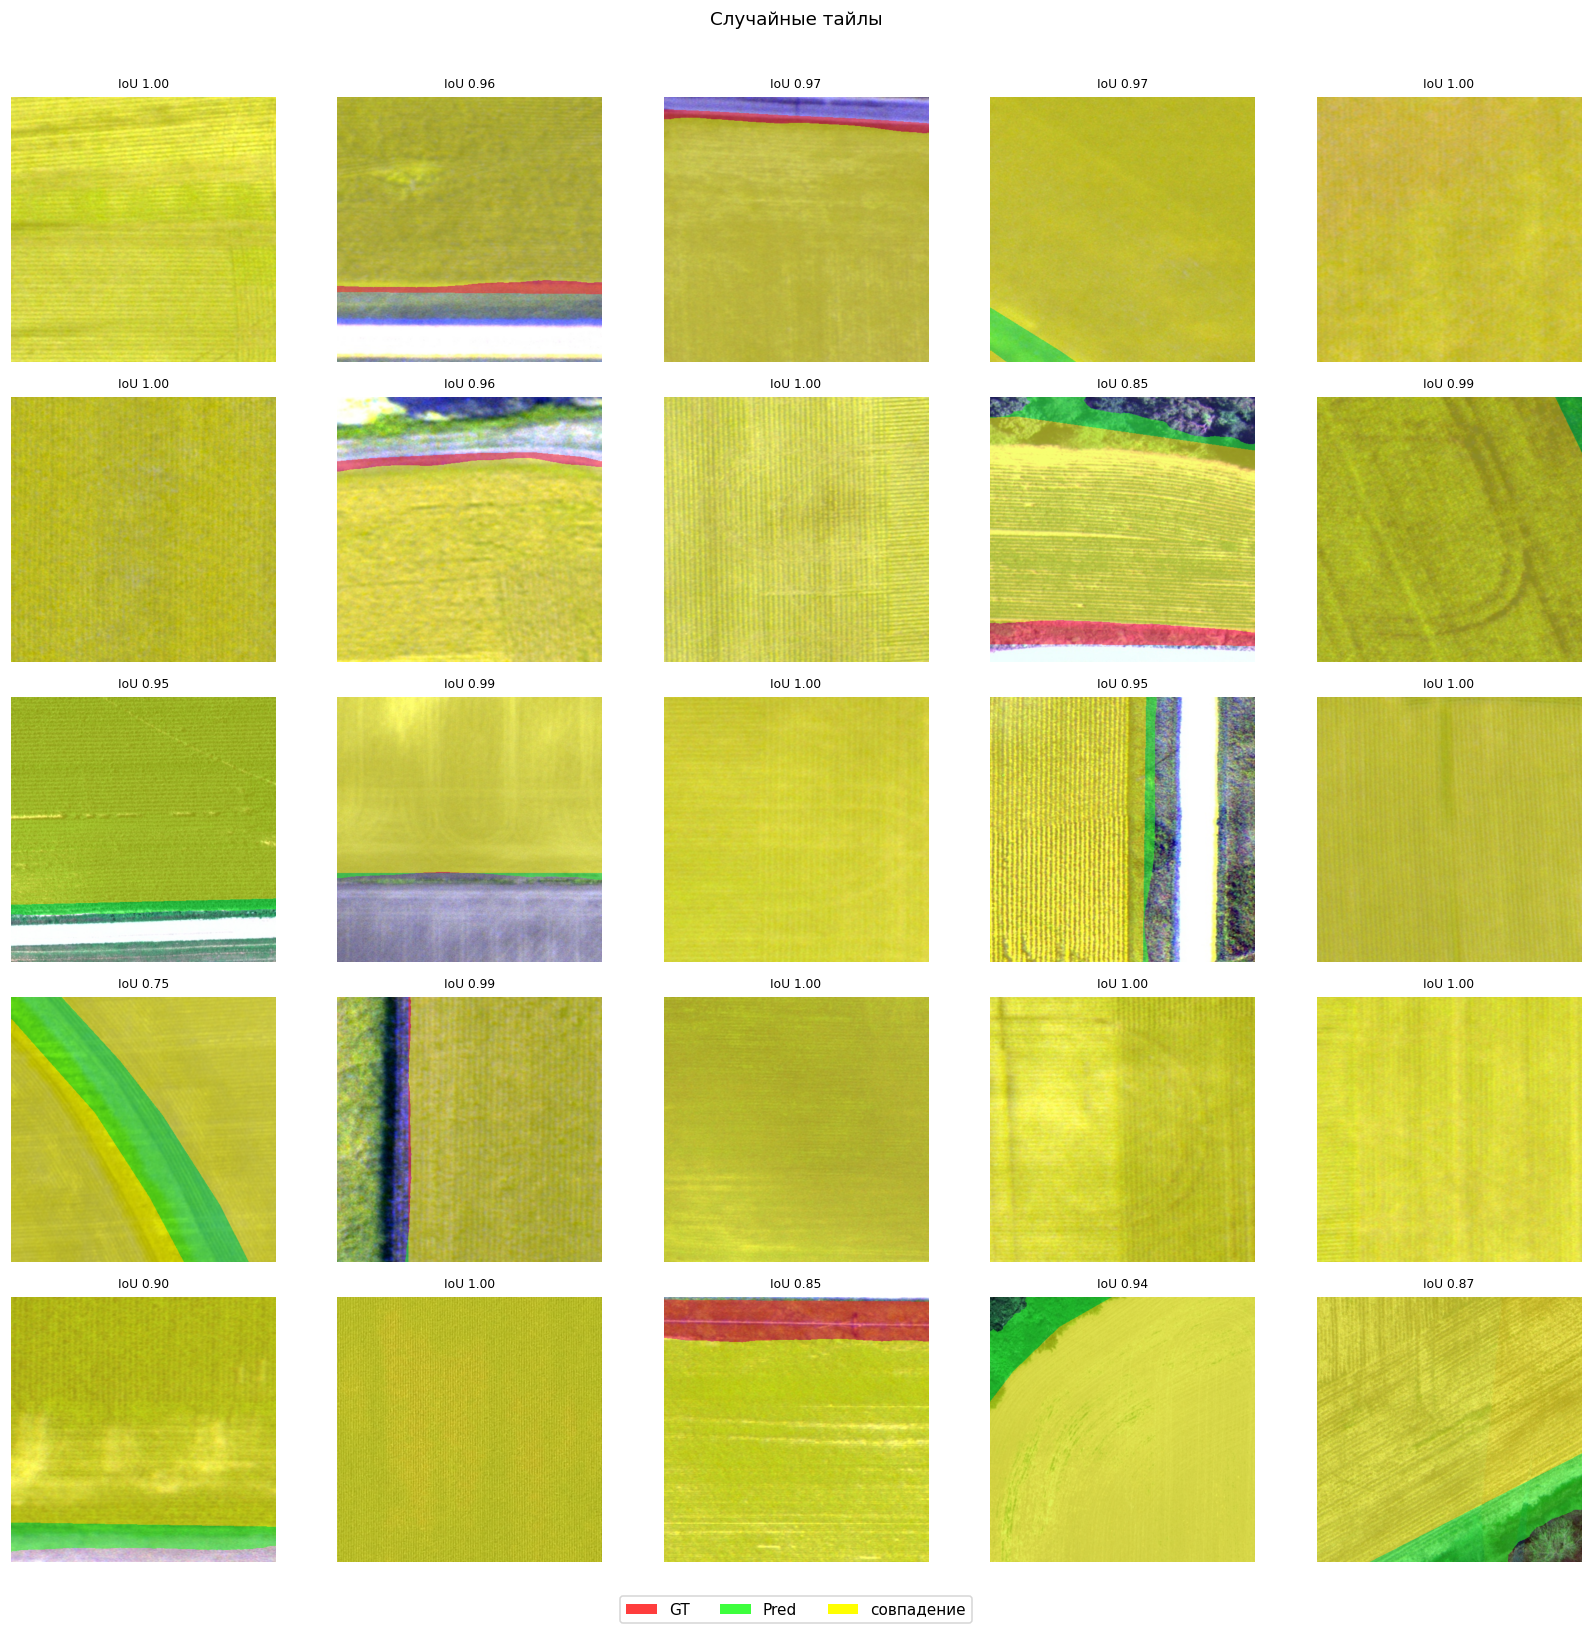

In [19]:
def _seg_overlay_rgb(
    rgb: np.ndarray,
    gt: np.ndarray,
    pred: np.ndarray,
    *,
    alpha_gt: float = 0.55,
    alpha_pred: float = 0.55,
    thickness: int = 2,
) -> np.ndarray:
    """Полупрозрачные границы на RGB: GT красный, Pred зелёный, overlap жёлтый."""
    base = rgb.astype(np.float32) / 255.0
    out = base.copy()

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (thickness, thickness))
    gt_d = cv2.dilate((gt > 0).astype(np.uint8), k)
    pr_d = cv2.dilate((pred > 0).astype(np.uint8), k)

    overlap = (gt_d > 0) & (pr_d > 0)
    gt_only = (gt_d > 0) & ~overlap
    pr_only = (pr_d > 0) & ~overlap

    def blend(mask: np.ndarray, color: tuple[float, float, float], alpha: float) -> None:
        if not mask.any():
            return
        c = np.array(color, dtype=np.float32)
        out[mask] = out[mask] * (1 - alpha) + c * alpha

    blend(gt_only, (1.0, 0.15, 0.15), alpha_gt)
    blend(pr_only, (0.15, 1.0, 0.15), alpha_pred)
    blend(overlap, (1.0, 1.0, 0.0), max(alpha_gt, alpha_pred))

    return (np.clip(out, 0, 1) * 255).astype(np.uint8)

N_GRID = 5
N_TILES = N_GRID * N_GRID

rng = random.Random()  
grid_stems = rng.sample([t["stem"] for t in per_tile], N_TILES)

grid_tiles = infer_tiles_for_viz(
    model, VAL_SPLIT_ROOT, grid_stems, device,
    tile_size=TILE_SIZE, threshold=THRESHOLD, tta=USE_TTA, fp16=FP16,
)

fig, axes = plt.subplots(N_GRID, N_GRID, figsize=(15, 15))
for ax, tile in zip(axes.ravel(), grid_tiles):
    vis = _seg_overlay_rgb(tile["rgb"], tile["gt"], tile["pred"], thickness=2)
    ax.imshow(vis)
    ax.set_title(f"IoU {tile['iou']:.2f}", fontsize=8)
    ax.axis("off")

legend = [
    Patch(facecolor=(1, 0.24, 0.24), label="GT"),
    Patch(facecolor=(0.24, 1, 0.24), label="Pred"),
    Patch(facecolor=(1, 1, 0), label="совпадение"),
]
fig.legend(handles=legend, loc="lower center", ncol=3, fontsize=10)
fig.suptitle(
    f"Случайные тайлы",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## Итог

Результаты полной валидации на val — в графиках выше.

- **IoU** = метрика из ячейки «Итоговые метрики»
- **ТЗ** = зелёные столбцы в pass/fail графике
- **Примеры** = худшие / медианные / лучшие тайлы и демо-кадр